# Model Selection — Seoul Bike Sharing 2015–2024 (Notebook 04)

In this fourth notebook of the v4 series, regression estimators are selected, optimized, and compared exclusively on development data. The final holdout remains sealed for Notebook 05. The joint search over estimator, representation, encoder, loss function, boosting-budget strategy, and target strategy remains the project's central contract.

The predictive objective is now defined as demand under normal operating conditions. Calendar year 2020 is preserved in the source and stress diagnostics, but its observations are not used for fitting or in the primary selection metric. All estimators are reevaluated under the same definition so that CatBoost cannot be promoted merely by inheriting a result from the previous regime.


## 1. Environment, Language, and Visualization Parameters

All execution is performed under the conda environment `Bike-Sharing`, and the verification is done by the interpreter itself through `sys.prefix` and `sys.executable`. The check is raised before loading the data, creating Optuna studies, and opening MLflow runs, so that an execution in an incorrect environment is interrupted before producing artifacts.

The environment report is displayed as audit evidence for the saved notebook, along with the versions of libraries that determine the results and the fingerprint that summarizes this set.

Brazilian Portuguese remains the canonical project edition. In this EN-US notebook, the `multilang` layer is accessed through `make_lang('en')` and applied to titles, reports, and visible outputs without translating internal variable names or parameters. Shared plotting parameters are reapplied to maintain a consistent presentation.


In [1]:
import logging
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

from src import model_selection_reports as reports
from src.i18n import make_lang
from src.model_selection_workflow import (
    load_model_selection_results,
    ModelSelectionConfig,
    prepare_development_data,
    run_model_selection,
    sample_dynamic_pipeline,
)
from src.normal_operations import NORMAL_OPERATIONS_SEED_TRIALS
from src.plotting import set_graph_parameters

warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('matplotlib.category').setLevel(logging.WARNING)

lang = make_lang('en')
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
reports.environment_report(lang=lang)

,Item,Value
0,Conda environment,Bike-Sharing
1,Interpreter (sys.executable),Bike-Sharing/python.exe
2,Python version,3.10.20
3,Environment fingerprint,8f80d9216d47a792
4,Differences from environment.yml,none
5,Dependencies declared with the model,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Declarative Execution Configuration

All execution is described by a single configuration. In `full` mode, Ridge, HistGradientBoosting, XGBoost, LightGBM, Random Forest, and CatBoost will be evaluated up to 100 trials or four hours per estimator, with the first limit reached taking precedence. The `smoke` mode limits each study to two trials and is used only to validate the complete flow before the final execution.

The `refined` profile maintains dynamic preprocessing conditioned on the estimator family. For XGBoost, LightGBM, and CatBoost, the budget strategy is also chosen by trial: the number of trees can be discovered by early stopping in an internal temporal tail or can be estimated directly as a fixed budget. The `target_transform='none'` transformation remains available only for direct CatBoost.

Competitive configurations from the previous protocol are queued as initial hypotheses and count towards the 100-trial limit. None of them is treated as an anticipated winner. The weights `(1, 1, 2, 3)` are associated, in this order, to the normal folds of 2019, 2021, 2022, and 2023. The 2020 fold is preserved as stress and does not receive weight in the selection.


In [3]:
config = ModelSelectionConfig(
    run_mode='full',  # smoke validado; execução definitiva: 100 trials ou 4 h
    estimators=(
        'Ridge',
        'HistGradientBoostingRegressor',
        'XGBRegressor',
        'LGBMRegressor',
    ),
    include_random_forest=True,
    include_catboost=True,
    trials_per_estimator=100,
    study_timeout=14_400.0,
    n_challengers=2,
    train_window_years=None,
    fold_weights=(1.0, 1.0, 2.0, 3.0),
    search_profile='refined',
    target_strategy='auto',
    selection_metric='cv_mae_weighted',
    candidates_root=PROJECT_ROOT / 'dataset' / 'normal_operations',
    enqueued_trials_by_estimator=NORMAL_OPERATIONS_SEED_TRIALS,
)
reports.run_configuration_report(config, lang=lang)

,Item,Value
0,Execution mode,full
1,Candidate estimators,"Ridge, HistGradientBoostingRegressor, XGBRegre..."
2,Trials per estimator (configured total),100
3,Trial timeout (s),1800.0
4,Study timeout (s),14400.0
5,Estimator-specific timeout (s),{}
6,Frozen challengers,2
7,Freeze final candidates,True
8,CV strategy version,ForwardMeteorologicalYearSplit_v3_normal_opera...
9,Code version,temporal_optimizer_v7


## 3. Data Preparation and Holdout Sealing

The final holdout is separated by date, from December 1, 2023, through November 30, 2024, rather than by row count. Observations from this period are discarded inside the splitting function, which returns only the development set and a summary without row-level data. At no point in this notebook is a variable containing holdout observations materialized.

Development is defined as the slice strictly preceding the start of the holdout. Because the source extends through December 31, 2024, the hours after the end of the holdout are also excluded from this workflow and remain only as a count in the report.

The normal-operations mask is created only after the holdout has been sealed. It identifies calendar year 2020 by timestamp, without consulting demand, and is recorded through a fingerprint. The source and the overall dataset fingerprint remain unchanged; only the subsets admitted for fitting and scoring are modified by the declared protocol.


In [4]:
development = prepare_development_data(config)
reports.holdout_seal_report(development, lang=lang)

,Item,Value
0,Development period,19/09/2015 — 30/11/2023
1,Development rows,"71,490"
2,Holdout period,01/12/2023 — 30/11/2024
3,Rows sealed in the holdout,"8,784"
4,Sealed,True
5,Discarded post-holdout period,01/12/2024 — 31/12/2024
6,Excluded post-holdout rows,744
7,Available folds,5
8,Dataset fingerprint,24f188a95febd94d
9,Regime fingerprint,1043b392ad5e2806


## 4. Meteorological Fold Auditing

Annual folds are audited before any model fitting. In each split, a complete meteorological year, from December through November, is reserved for testing; thus, winter, spring, summer, and autumn are represented without introducing future years into training.

The sliding window remains the primary configuration, and the 48-hour gap is measured by actual timestamps. The report distinguishes rows available within the window from rows eligible for fitting. It also identifies the four selection folds and the 2020 fold, which is calculated exclusively as a stress diagnostic.

The geometry is also represented on a timeline. Eligible training rows, 2020 hours excluded from fitting, the gap, selection tests, and stress tests are distinguished. In the 2021 meteorological fold, December 2020 is shown separately because it belongs to the annual test window but does not contribute to the normal score.


,Fold,Training start,Training end,Test start,Test end,Training rows,Test rows,Actual gap (hours),Seasons in test set,Training contains future years,Meteorological year,Protocol role,Eligible training rows,Excluded training rows,Rows used for selection
0,1,2015-09-19,2018-11-28 23:00:00,2018-12-01,2019-11-30 23:00:00,27689,8715,49.0,"Autumn, Spring, Summer, Winter",False,2019,selection,27689,0,8715
1,2,2015-09-19,2019-11-28 23:00:00,2019-12-01,2020-11-30 23:00:00,36404,8759,49.0,"Autumn, Spring, Summer, Winter",False,2020,stress,36404,0,0
2,3,2015-09-19,2020-11-28 23:00:00,2020-12-01,2021-11-30 23:00:00,45163,8760,49.0,"Autumn, Spring, Summer, Winter",False,2021,selection,37196,7967,8016
3,4,2015-09-19,2021-11-28 23:00:00,2021-12-01,2022-11-30 23:00:00,53923,8759,49.0,"Autumn, Spring, Summer, Winter",False,2022,selection,45164,8759,8759
4,5,2015-09-19,2022-11-28 23:00:00,2022-12-01,2023-11-30 23:00:00,62682,8760,49.0,"Autumn, Spring, Summer, Winter",False,2023,selection,53923,8759,8760


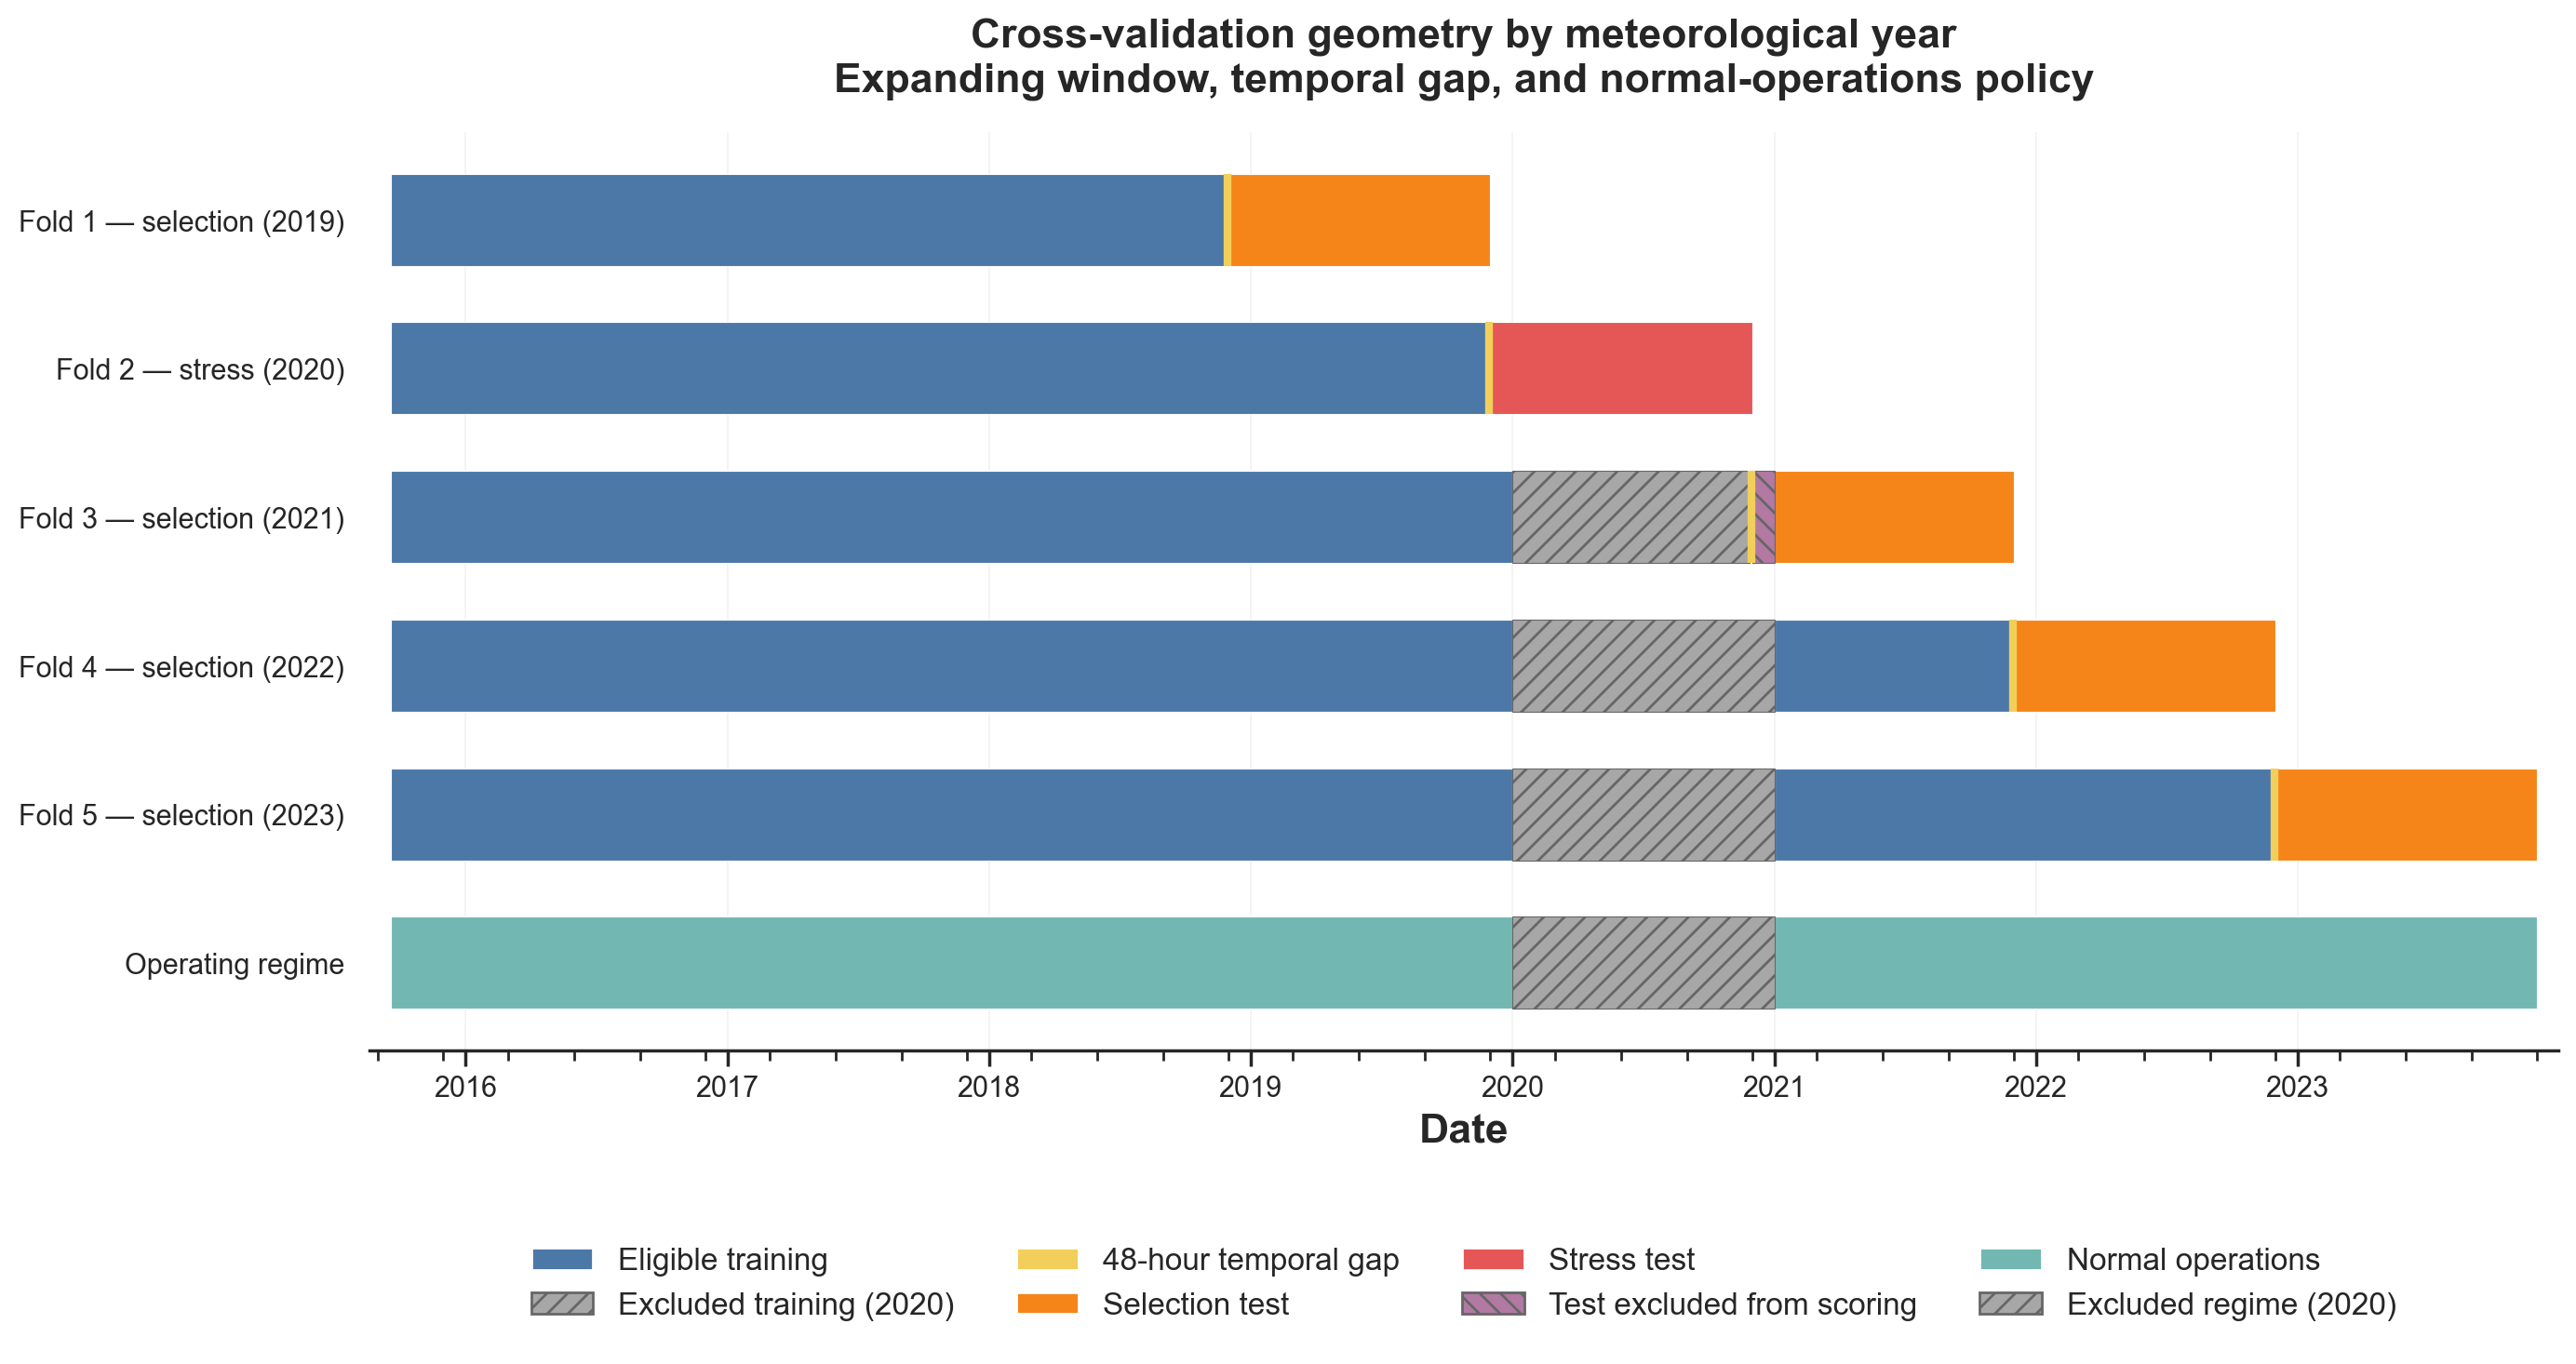

In [5]:
display(reports.fold_audit_report(development, lang=lang))
reports.plot_fold_audit(development, lang=lang)

> ### Insight
>
> The regime change was treated as an explicit redefinition of the objective rather than opportunistic data cleaning. Calendar year 2020 was preserved in the source, dataset fingerprint, and meteorological stress fold, but its rows were excluded from fitting and from the metric used to select the champion.
>
> In the 2021 meteorological fold, December 2020 was also excluded from normal scoring. Therefore, no hour from the declared interval contributes partially to the objective merely because it crosses the boundary between a calendar year and a meteorological year.
>
> In the diagram, the gray gap in training after 2020 does not represent missing data; it documents observations deliberately prevented from contributing to model fitting. The red block remains a stress test, while only the orange blocks contribute to the selection criterion.


## 5. Candidate Features and Their Pipeline Branches

The new weather variables, the `Rush_Period` category, and `Elapsed_Hours`, which is derived only from the timestamp, are retained in the candidate space. `Year` remains excluded because it could directly represent the accumulated growth curve. `is_anomalous_2020` is also withheld from the model because it was retrospectively derived from demand.

Continuous and categorical representations of sunshine and cloud cover deliberately coexist. Redundancy is resolved by the feature selectors within the search. Missing values are imputed inside the corresponding branch, using statistics learned only from the training data of each fold.


In [6]:
reports.feature_space_report(config, lang=lang)

,Candidate feature,Preprocessing branch
0,Temperature(C),Numerical
1,Dew point temperature(C),Numerical
2,Ground Temp(C),Numerical
3,Humidity(%),Numerical
4,Solar Radiation (MJ/m2),Numerical
5,Wind speed (m/s),Numerical
6,Visibility (10m),Numerical
7,Sunshine (hr),Numerical
8,Cloud Cover (oktas),Numerical
9,Month,Numerical


## 6. Dynamic Estimator-Conditional Preprocessing

Preprocessing is not fixed in advance. For every trial, `modeler_name`, the encoder, loss function, hyperparameters, boosting-budget strategy, and target strategy are selected jointly and conditioned on the estimator family.

Under the refined profile, `NoSelector` is retained for boosting estimators based on evidence from the exploratory search, while Ridge may still evaluate selectors compatible with its coefficients. The substantive choices of temporal representation and categorical encoding remain dynamic.

Under the direct strategy, `log1p` remains available to estimators in general, whereas the untransformed target is reopened only for CatBoost. Under `robust_trend_residual`, a log-linear trend with monthly seasonality is estimated exclusively from eligible training rows, and the pipeline learns the logarithmic residual. Demand is reconstructed on its original scale before the metrics are calculated.


In [7]:
reports.search_space_report(config, lang=lang)

,Estimator,Family,Available strategies,Representation space (modeler_name),Encoder space,Feature-selection space,Boosting-budget space
0,DummyRegressor,baseline,1,linear_modeling,"OrdinalEncoder, MeanEncoder, CountFrequencyEnc...",NoSelector,not applicable
1,Ridge,linear,8,"linear_modeling, Normalizers, Polynomial, Sin_...","OrdinalEncoder, MeanEncoder, CountFrequencyEnc...","NoSelector, SelectKBest, RFE, SelectFromModel,...",not applicable
2,HistGradientBoostingRegressor,hist_gradient_boosting,1,Periodic_Spline,"MeanEncoder, CountFrequencyEncoder",NoSelector,not applicable
3,XGBRegressor,xgboost,1,linear_modeling,"JamesSteinEncoder, CountFrequencyEncoder",NoSelector,"temporal_early_stopping, fixed_iterations"
4,LGBMRegressor,lightgbm,1,linear_modeling,"CountFrequencyEncoder, QuantileEncoder",NoSelector,"temporal_early_stopping, fixed_iterations"
5,RandomForestRegressor,tree_ensemble,2,"linear_modeling, Periodic_Spline","OrdinalEncoder, CountFrequencyEncoder",NoSelector,not applicable
6,CatBoostRegressor,catboost,1,Periodic_Spline,"OrdinalEncoder, MeanEncoder, CountFrequencyEnc...",NoSelector,"temporal_early_stopping, fixed_iterations"


> ### Insight
>
> The project's signature architecture was extended without compromising its design: the regime policy controls which rows may be used for fitting, while representation, encoding, selection, target transformation, and booster-budget decisions remain encapsulated in the dynamic pipeline and are selected jointly by Optuna.
>
> The old CatBoost configuration and the best arrangements of the other estimators were reused only as initial trials. Thus, accumulated knowledge was preserved without preventing each family from being judged again under the same normal operations view.


## 7. A Sampled Dynamic Pipeline

A pipeline is built with fixed choices solely to inspect its structure. The conceptual order is preserved: target-independent feature engineering, estimator-family-conditional representation, categorical encoding, feature selection, target strategy, and regressor.

When decomposition is selected, the outer meta-estimator receives the original features, estimates the trend exclusively from eligible training rows, and delegates residual learning to the same dynamic pipeline. The regime policy is not converted into a feature and cannot be learned by the estimator.


In [8]:
sample_pipeline, sample_spec = sample_dynamic_pipeline(development, estimator='Ridge')
display(reports.pipeline_spec_report(sample_spec, lang=lang))
reports.dynamic_pipeline_diagram(sample_pipeline)

,Item,Value
0,Estimator,Ridge
1,Family,linear
2,Representation (modeler_name),Periodic_Spline
3,Categorical encoder,MeanEncoder
4,Numerical scaler,StandardScaler
5,Normalizer,not used
6,Feature selector,SelectKBest
7,Target transformation,log1p
8,Boosting-budget strategy,not used
9,Features supplied to the estimator,not used


## 8. Normal Operations Definition and Stress Diagnostics

The period from January 1 through December 31, 2020, was declared an operational-break interval before the search. The rule is entirely temporal and does not depend on a demand threshold, preventing the target from being used to decide which observations are excluded.

Rows from this interval are not used to fit any fold, in the final refit, or in the primary metric. The complete 2020 meteorological fold continues to be predicted, and its full metrics are recorded as stress diagnostics. In selection folds, complete normal metrics and complete diagnostic metrics are retained side by side whenever their respective blocks contain excluded hours.

This separation answers two distinct questions. The ranking measures the ability to predict demand under the declared operational objective, whereas the stress diagnostics document how the same pipeline would behave under the preserved historical disruption.


## 9. Joint Search Execution

The search is performed by a single workflow call. New studies are identified by code version, fold geometry, weights, policy, fingerprint, search profile, target strategy, dataset, and numerical environment; results produced by previous protocols cannot be silently appended.

For XGBoost, LightGBM, and CatBoost, temporal early stopping and fixed budget compete as explicit strategies. When early stopping is chosen, an internal tail is removed only from the eligible training of each fold. When the fixed budget is chosen, the number of iterations is sampled, and the annual test continues reserved exclusively for scoring.

In the `full` mode, each study is terminated upon reaching 100 trials or four cumulative hours. The queued configurations count towards this total, and a restart uses only the available trials and time.

Because the definitive search has already been completed, the published execution uses the lightweight snapshot of the validated results by default. This artifact contains only specifications and aggregated CV diagnostics; models, Optuna studies, predictions, and holdout observations are not deserialized. A new search is started only when `RETRAIN_MODELS` is explicitly changed to `True`.


In [9]:
RETRAIN_MODELS = False

if RETRAIN_MODELS:
    results = run_model_selection(config, development)
else:
    results = load_model_selection_results(config, development)

> ### Insight
>
> The `full` search was completed for the six candidate estimators and the baseline. CatBoost, HistGradientBoosting, Random Forest, LightGBM, and XGBoost reached the planned 100 trials; Ridge completed 66 trials before reaching the four-hour limit. Because Ridge remained well outside the leading group, this interruption should be interpreted as a limitation on the breadth of its search rather than evidence capable of changing the top of the ranking.
>
> The improvement was not restricted to a single estimator family. Under the normal-operations protocol, CatBoost, HistGradientBoosting, and Random Forest formed a competitive group, with weighted R² between 0.839 and 0.857 and mean MAE between 815 and 848 bicycles per hour. In contrast, DummyRegressor produced a weighted MAE of 3,652 and weighted R² of −0.988, demonstrating that the leading models learned generalizable temporal and meteorological structure.
>
> No systematic truncation at the boosting ceiling was recorded. For the winning CatBoost configuration, Optuna selected 497 fixed iterations, whereas LightGBM used 1,102 aggregated early-stopping iterations. A single LightGBM fold reached the ceiling, but this isolated event was not mistaken for systematically constrained convergence.


## 10. Cross-Validation Comparison

The estimators are ranked by recency-weighted mean absolute error (MAE). Unweighted mean MAE, root mean squared error (RMSE), weighted absolute percentage error (WAPE), mean R², median R², weighted R², and mean absolute fold bias are also displayed so that the decision is not interpreted from a single number.

The aggregated selection metrics use only 2019, 2021, 2022, and 2023. The complete metrics for the 2020 fold remain available in the fold diagnosis, but cannot change the champion's position.


,Estimator,Role,Representation,Encoder,Scaler,Selector,Target,Boosting budget,Features,Mean normal MAE (CV),...,Mean normal WAPE (CV),Mean normal bias (CV),Mean |bias| per fold,R² gap (train-test),Planned trials,Completed trials,Termination reason,Final-refit iterations,Folds at the boosting ceiling,Run ID
0,CatBoostRegressor,champion,Periodic_Spline,OrdinalEncoder,passthrough,NoSelector,robust_trend_residual,fixed_iterations,41,820.401191,...,0.235199,-400.501401,518.126115,0.139722,100,100,trial limit,497.0,0,2106a5bf79e945f7a4a9d161e2ee01d3
1,HistGradientBoostingRegressor,candidate,Periodic_Spline,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,41,815.019786,...,0.227961,-359.628940,489.208495,0.135518,100,100,trial limit,NaN,0,381e7061d8ef440e917c792ab38e59f3
2,RandomForestRegressor,candidate,linear_modeling,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,25,847.613928,...,0.235579,-240.020959,425.603402,0.152546,100,100,trial limit,NaN,0,030ef18ea01d46caacbeb2bc0765da61
3,LGBMRegressor,candidate,linear_modeling,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,temporal_early_stopping,25,936.177127,...,0.250890,-241.507045,574.275904,0.142894,100,100,trial limit,1102.0,1,7a848d2ed71341fa9a4fd7424488e901
4,XGBRegressor,candidate,linear_modeling,JamesSteinEncoder,passthrough,NoSelector,log1p,fixed_iterations,25,1146.470075,...,0.331883,-939.330722,939.330722,0.273618,100,100,trial limit,420.0,0,9795292e8c384852ab6b6538ef6a15b5
5,Ridge,candidate,Time_steps_as_categories,JamesSteinEncoder,StandardScaler,SequentialFeatureSelector,robust_trend_residual,None,10,1293.085149,...,0.343111,527.621047,582.029203,0.036616,100,66,study timeout,NaN,0,d4b297ac317d4a6683520bec9b15e6d6
6,DummyRegressor,baseline,linear_modeling,QuantileEncoder,RobustScaler,NoSelector,yeo_johnson,None,25,3237.243006,...,0.884902,-3190.739960,3190.739960,0.806281,3,3,trial limit,NaN,0,51e98fe59af44b9ebca9ba870e32958c


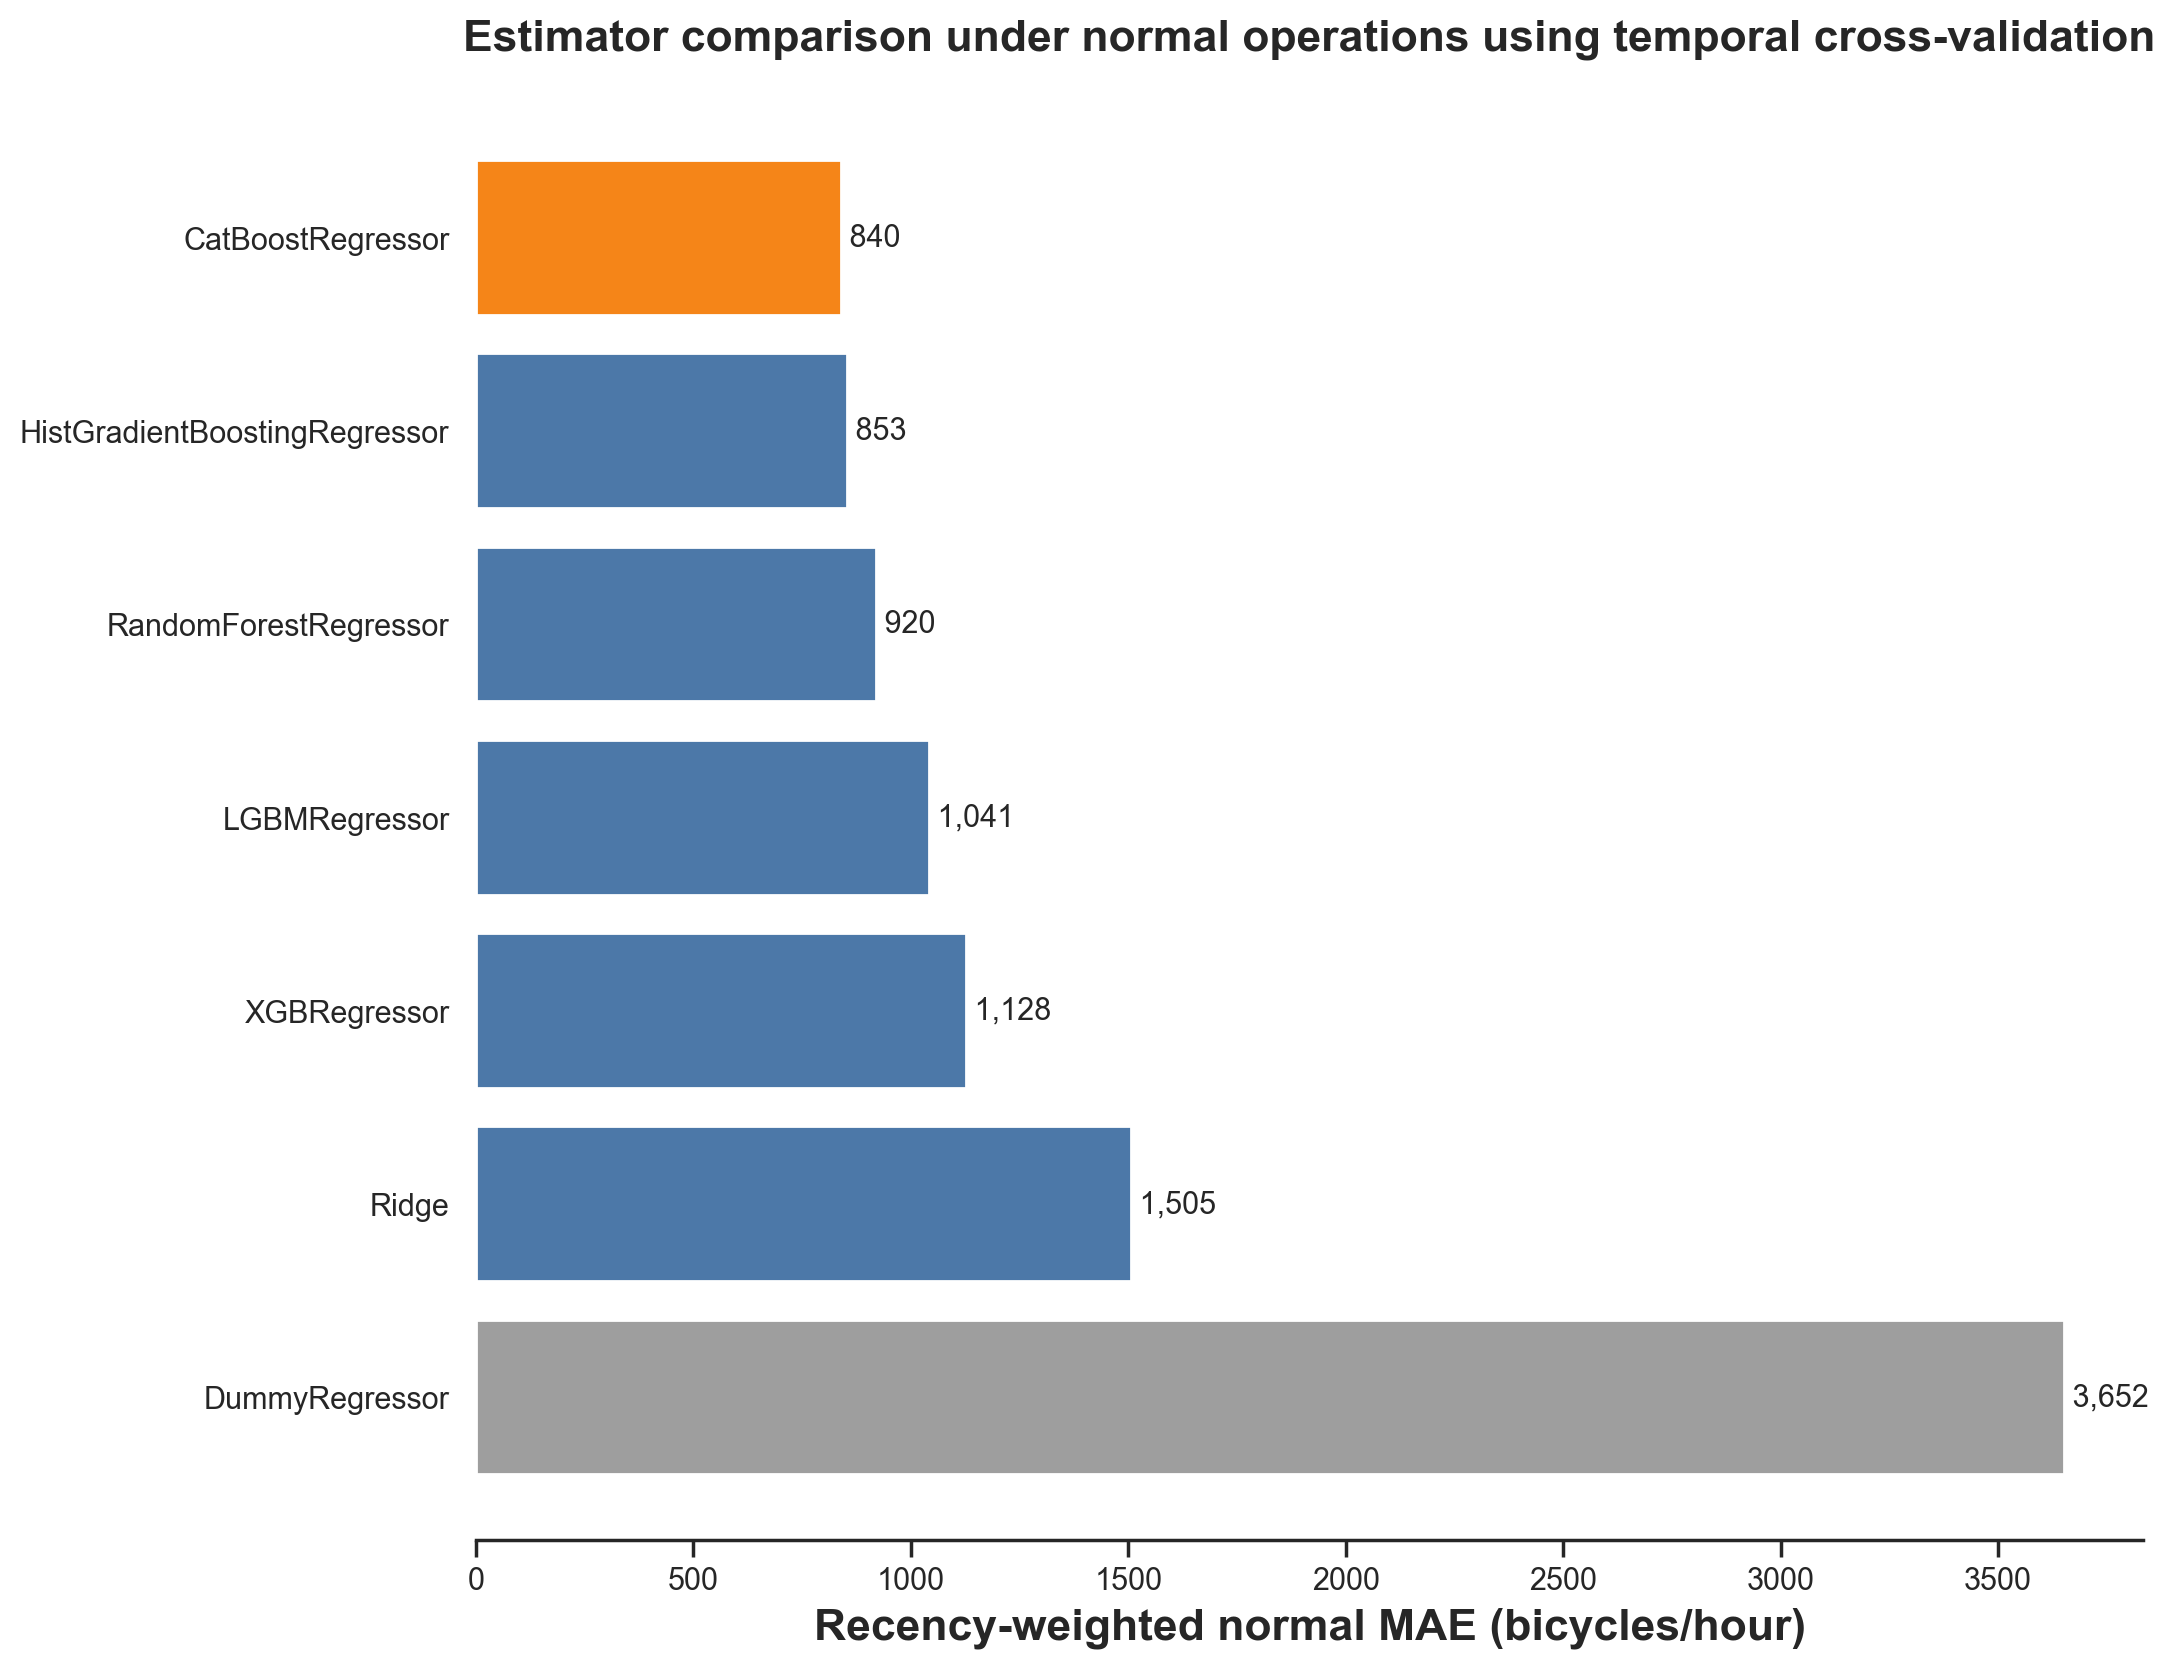

In [10]:
display(reports.comparison_report(results, lang=lang))
reports.plot_comparison(results, lang=lang)

> ### Insight
>
> CatBoost was selected based on the declared criterion, with a weighted mean absolute error (MAE) of 840.2, a weighted R² of 0.857, and a mean R² of 0.839. A reduction of approximately 77% in the weighted MAE was achieved compared to the DummyRegressor. In the four normal folds, R² values between 0.810 and 0.918 were maintained, which supports the observed stability and rules out the hypothesis that the aggregated result was produced by an exceptional single year.
>
> However, the leadership was narrow and dependent on the selection metric. A weighted MAE of 853.0 was obtained by HistGradientBoosting, which presented a slightly lower average MAE of 815.0 compared to 820.4, as well as a lower average WAPE and higher average and median R². The Random Forest presented a weighted MAE of 919.7 and the lowest average value of |bias| among the top three. Therefore, CatBoost was correctly frozen as the champion, but HistGradientBoosting and Random Forest were preserved as substantial challengers, and not just formal ones.


## 11. Diagnostics by Fold, Season, and Weather Extremes

The selected candidate's performance is decomposed by fold. Normal metrics are shown for the selection folds, while complete diagnostic metrics are preserved for every fold, including the 2020 stress fold. Counts of excluded training rows and actually scored test rows make the effect of the regime policy auditable.

Diagnostics by season and thermal extremes are calculated only from normal rows in the selection folds. Therefore, the weather comparison does not silently reintroduce the regime that was removed from the primary objective.


In [11]:
display(reports.fold_metrics_report(results, lang=lang))
reports.condition_metrics_report(results, lang=lang)

,Estimator,Fold,Meteorological year,Role,Training rows,Excluded training rows,Test rows,Test rows used for selection,Full-diagnostic MAE,Full-diagnostic RMSE,...,Normal-regime MAE,Normal-regime RMSE,Normal-regime R²,Normal-regime WAPE,Normal-regime bias,Full-diagnostic WAPE,Full-diagnostic bias,Iterations (early stopping),Iteration ceiling,Reached the ceiling
0,CatBoostRegressor,1,2019,selection,27689,0,8715,8715,531.067463,782.778501,...,531.067463,782.778501,0.815006,0.261463,-459.828516,0.261463,-459.828516,NaN,NaN,False
1,CatBoostRegressor,2,2020,stress,36404,0,8759,0,1478.114135,2176.171092,...,NaN,NaN,NaN,NaN,NaN,1.418034,1438.243498,NaN,NaN,False
2,CatBoostRegressor,3,2021,selection,37196,7967,8760,8016,900.347549,1232.299148,...,907.303424,1252.009734,0.812032,0.282839,-481.345596,0.304339,-370.466294,NaN,NaN,False
3,CatBoostRegressor,4,2022,selection,45164,8759,8759,8759,1086.914530,1724.726290,...,1086.914530,1724.726290,0.810150,0.245017,-896.080920,0.245017,-896.080920,NaN,NaN,False
4,CatBoostRegressor,5,2023,selection,53923,8759,8760,8760,756.319349,1211.868065,...,756.319349,1211.868065,0.917577,0.151479,235.249426,0.151479,235.249426,NaN,NaN,False


,Estimator,Scope,Condition,Observations,MAE,RMSE,R²
0,CatBoostRegressor,season,Autumn,8691,1169.254655,1589.391461,0.752003
1,CatBoostRegressor,season,Spring,8832,741.801805,1106.493487,0.864830
2,CatBoostRegressor,season,Summer,8831,998.015360,1333.517171,0.823180
3,CatBoostRegressor,season,Winter,7896,333.751742,494.850768,0.808177
4,CatBoostRegressor,temperature band,cold extreme (coldest 5%),1739,248.852188,375.075004,NaN
5,CatBoostRegressor,temperature band,hot extreme (hottest 5%),1757,1207.082927,1518.860336,NaN


> ### Insight
>
> For CatBoost, R² values of 0.815, 0.812, 0.810, and 0.918 were obtained in the normal folds of 2019, 2021, 2022, and 2023, respectively. Although MAE ranged from 531 to 1,087 bicycles per hour, the explained proportion of variance remained above 0.81 in every admitted year. In 2023, the lowest WAPE (0.151) and highest R² (0.918) were observed simultaneously, favoring CatBoost when recent folds received greater weight.
>
> In the 2020 stress fold, MAE of 1,478, WAPE of 1,418, R² of −2.355, and a positive bias of 1,438 bicycles per hour were recorded. This collapse outside the normal regime should not be used to reorder the candidates, but it confirms that the model cannot be presented as valid for a similar operational rupture. The exclusion of the pandemic made the normal objective more coherent; it did not transform the excluded event into a resolved scenario.
>
> Difficulty was also uneven across normal operating conditions. Autumn produced an MAE of 1,169 and R² of 0.752, whereas winter produced an MAE of 334. Across temperature extremes, the error under extreme heat (1,207) was almost five times that under extreme cold (249). These slices should guide residual validation and SHAP interpretation in Notebook 05, especially when examining whether underestimation of high demand is concentrated in warm periods and autumn.


## 12. Champion and Challengers

The champion and two challengers were identified among compatible MLflow runs and ordered by weighted mean absolute error (MAE). Exact matches for dataset, CV strategy, code version, environment, Git state, policy, and regime fingerprint were required.

No holdout metrics were consulted. CatBoost was promoted by the weighted MAE of 840.2, followed by HistGradientBoosting, with 853.0, and Random Forest, with 919.7. The proximity between the top two and secondary advantages observed for the challengers justify that all three be sent to final validation, without treating the cross-validation ranking as an early conclusion about the holdout.


In [12]:
reports.selection_report(results, lang=lang)

,Role,Estimator,Mean normal MAE (CV),Representation,Encoder,Scaler,Selector,Target,Boosting budget,Final-refit iterations,Folds at the boosting ceiling,Completed trials,Termination reason,Mode,Run ID
0,champion,CatBoostRegressor,820.401191,Periodic_Spline,OrdinalEncoder,passthrough,NoSelector,robust_trend_residual,fixed_iterations,497,0,100,trial limit,full,2106a5bf79e945f7a4a9d161e2ee01d3
1,challenger,HistGradientBoostingRegressor,815.019786,Periodic_Spline,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,None,0,100,trial limit,full,381e7061d8ef440e917c792ab38e59f3
2,challenger,RandomForestRegressor,847.613928,linear_modeling,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,None,0,100,trial limit,full,030ef18ea01d46caacbeb2bc0765da61


## 13. Artifacts and Handoff to Notebook 05

The selected candidates are persisted in `dataset/normal_operations`, accompanied by a manifest that records the run, estimator, execution mode, code and validation versions, dataset, environment, and regime fingerprints, hyperparameters, complete pipeline combination, final iteration budget, termination reason, model URI, and validation metrics.

The correspondence between run and pipeline is verified within the delivered object through a provenance stamp. The model is registered with pinned dependencies and the source code required for deserialization. In `full` mode, the run is rejected when the artifact cannot be reloaded in a self-contained manner.

Final candidate freezing is also rejected when an early-stopped booster shows systematic truncation at the ceiling. This check is not applied to a trial that deliberately selected a fixed budget, because in that case the number of trees is an evaluated hyperparameter rather than an accidental limit.


In [13]:
reports.handoff_report(results, lang=lang)

,Item,Value
0,Execution mode,full
1,Provisional artifacts,False
2,Manifest saved to,dataset/normal_operations/candidates_v4/candid...
3,MLflow experiment,bike_sharing_demand_v4_model_selection
4,Champion run ID,2106a5bf79e945f7a4a9d161e2ee01d3
5,Champion model URI,runs:/2106a5bf79e945f7a4a9d161e2ee01d3/model
6,Dataset fingerprint,24f188a95febd94d
7,Regime policy,normal_operations
8,Regime fingerprint,1043b392ad5e2806
9,Runtime environment,Bike-Sharing (8f80d9216d47a792)


> ### Insight
>
> The final manifest was recorded in `dataset/normal_operations/candidates_v4`, and the self-contained CatBoost, HistGradientBoosting, and Random Forest artifacts were verified after registration. The champion was associated with run `2106a5bf79e945f7a4a9d161e2ee01d3`, under the `Bike-Sharing` environment and regime fingerprint `1043b392ad5e2806`.
>
> The normal-operations policy was carried in the manifest and MLflow tags. Therefore, a model selected over all years cannot be confused with a candidate produced under the new objective, even when the estimator and original dataset are the same. Notebook 05 can consume the three artifacts without reopening the search and remains the only authorized point at which the holdout may be materialized and evaluated.


## 14. Preserved Architecture and Deviations from v3

The dynamic estimator-conditioned preprocessing architecture was preserved. The regime policy was added as a row-eligibility restriction, while trend correction remains encapsulated as the pipeline's target strategy.

The refined space was expanded where evidence required a new comparison. XGBoost, LightGBM, and CatBoost can choose between temporal early stopping and fixed iterations; all estimators receive another opportunity to compete under the normal objective; and previously competitive configurations are evaluated before free sampling.

The native categorical mode of CatBoost is still not activated. The comparison remains based on the shared encoders of the dynamic architecture, ensuring that the change of this round is attributable to the regime and the boosting budget, and not to the simultaneous introduction of an exclusive categorical interface.


## 15. Synthesis

The selection objective was redefined as demand forecasting under normal operating conditions. Calendar year 2020 was preserved as historical evidence and a stress diagnostic, but was excluded from fold fitting, the final refit, and the primary metric by a declared temporal rule that does not consult the target.

Four meteorological folds were used in the selection, with increasing weights for 2022 and 2023. The 2020 fold was forecast and reported separately. The distinction between normal and diagnostic metrics prevented the break from dominating the ranking again, while also avoiding its effect from being hidden.

All estimators were evaluated again. CatBoost, HistGradientBoosting, and Random Forest formed the leading group, with weighted R² between 0.839 and 0.857. The `robust_trend_residual` strategy was selected for the three, although distinct representations and encoders were chosen by the dynamic pipeline. XGBoost preferred the direct strategy with `log1p`, but remained below the leading group, demonstrating that the response to the new regime definition depended on the combination between estimator and preprocessing.

CatBoost was frozen as champion by the weighted normal MAE of 840.2, but the difference of only 12.8 bicycles per hour to HistGradientBoosting was small. HistGradientBoosting presented better MAE, WAPE, and median R², while Random Forest presented the smallest |bias| among the top three. Thus, the champion's choice was respected without erasing evidence favorable to the challengers.

The proposal's stability was supported by R² above 0.81 in the champion's four normal folds and by its wide margin over the baseline. Validity nevertheless remained restricted to normal operating conditions: the 2020 stress fold produced an R² of -2.355, and the largest normal errors were concentrated in autumn and extreme heat. In Notebook 05, the untouched holdout should be used once for comparative validation, residual analysis, and SHAP interpretation of the three frozen candidates.
